# 01 - What survival analysis is actually for

Imagine you advise a subscription business. A normal classifier asks:

> Will this customer churn?

Survival analysis asks the sharper question:

> How long until churn, and how should we use customers we have not observed long enough yet?

That last clause is the whole point. In real projects, many customers are still active when the dataset is pulled. They are not "non-churners forever." They are **right-censored**: we know they survived at least this long, and the future is still unknown.

## The three columns that make a survival dataset

Every survival project needs a clear answer to these questions:

| Question | Modeling name | Example |
|---|---|---|
| When does the stopwatch start? | time zero | trial start, diagnosis date, signup date |
| What event are we waiting for? | event | churn, death, default, activation, machine failure |
| How long did we observe the person/item? | duration | days from time zero until event or last observation |
| Did the event actually happen? | event indicator | 1 if observed, 0 if censored |

If those are blurry, the model will be blurry too.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"
OUTPUT_DIR = INTRO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
df = pd.read_csv(DATA_DIR / "tiny_customer_churn_timeline.csv")
df

,customer_id,pilot_group,days_since_trial_start,churn_observed,plain_english_status
0,C001,Team A,4,1,Churned after onboarding friction
1,C002,Team A,6,1,Churned after missing setup
2,C003,Team B,6,0,Still active when data was extracted
3,C004,Team B,9,1,Churned after first invoice
4,C005,Team A,11,0,Still active when data was extracted
5,C006,Team C,12,1,Churned after support delay
6,C007,Team C,15,0,Still active when data was extracted
7,C008,Team B,18,1,Churned after low usage
8,C009,Team A,21,0,Still active when data was extracted
9,C010,Team C,24,1,Churned after renewal reminder


## Read one row in plain English

`days_since_trial_start = 15` and `churn_observed = 0` means:

> We watched this customer for 15 days. They had not churned yet when the data was extracted.

It does **not** mean:

> This customer will never churn.

That distinction is why survival analysis exists.

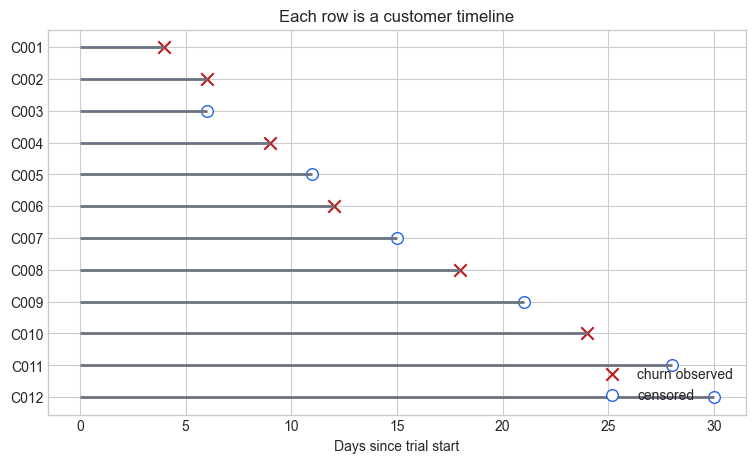

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(df))
ax.hlines(y=y_pos, xmin=0, xmax=df["days_since_trial_start"], color="#6B7280", linewidth=2)

events = df["churn_observed"].eq(1)
ax.scatter(df.loc[events, "days_since_trial_start"], y_pos[events], marker="x", s=80, color="#B91C1C", label="churn observed")
ax.scatter(df.loc[~events, "days_since_trial_start"], y_pos[~events], marker="o", s=70, facecolor="white", edgecolor="#2563EB", label="censored")

ax.set_yticks(y_pos)
ax.set_yticklabels(df["customer_id"])
ax.invert_yaxis()
ax.set_xlabel("Days since trial start")
ax.set_title("Each row is a customer timeline")
ax.legend(loc="lower right")
plt.show()

## Kaplan-Meier by hand

Kaplan-Meier is just careful bookkeeping over time.

At each event time:

1. Count how many customers were still at risk right before that time.
2. Count how many events happened at that time.
3. Multiply the previous survival probability by `1 - events / at_risk`.

Censored customers reduce the future risk set, but they do not create a downward step in the curve because the event was not observed.

In [4]:
event_times = sorted(df.loc[df["churn_observed"].eq(1), "days_since_trial_start"].unique())
rows = []
survival = 1.0

for t in event_times:
    at_risk = (df["days_since_trial_start"] >= t).sum()
    observed = ((df["days_since_trial_start"] == t) & df["churn_observed"].eq(1)).sum()
    censored = ((df["days_since_trial_start"] == t) & df["churn_observed"].eq(0)).sum()
    survival *= 1 - observed / at_risk
    rows.append(
        {
            "event_day": t,
            "at_risk_before_day": at_risk,
            "churn_events_on_day": observed,
            "censored_on_day": censored,
            "survival_after_day": survival,
        }
    )

manual_km = pd.DataFrame(rows)
manual_km

,event_day,at_risk_before_day,churn_events_on_day,censored_on_day,survival_after_day
0,4,12,1,0,0.916667
1,6,11,1,1,0.833333
2,9,9,1,0,0.740741
3,12,7,1,0,0.634921
4,18,5,1,0,0.507937
5,24,3,1,0,0.338624


Median survival time: 24.0


,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,12,12
4.0,1,1,0,0,12
6.0,2,1,1,0,11
9.0,1,1,0,0,9
11.0,1,0,1,0,8
12.0,1,1,0,0,7
15.0,1,0,1,0,6
18.0,1,1,0,0,5
21.0,1,0,1,0,4


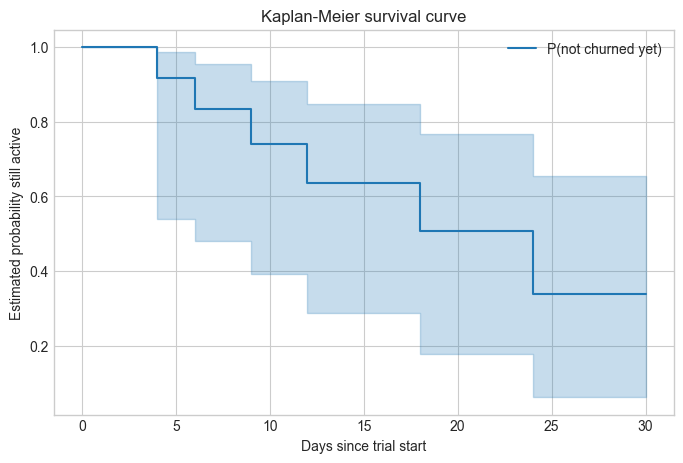

In [5]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(
    durations=df["days_since_trial_start"],
    event_observed=df["churn_observed"],
    label="P(not churned yet)",
)

print("Median survival time:", kmf.median_survival_time_)
display(kmf.event_table.head(10))

ax = kmf.plot_survival_function(figsize=(8, 5), ci_show=True)
ax.set_title("Kaplan-Meier survival curve")
ax.set_xlabel("Days since trial start")
ax.set_ylabel("Estimated probability still active")
plt.show()

In [6]:
horizons = [7, 14, 21, 30]
survival_at_horizons = kmf.survival_function_at_times(horizons).rename("survival_probability")
pd.DataFrame(
    {
        "day": horizons,
        "P(still active at day)": survival_at_horizons.values.round(3),
        "P(churned by day)": (1 - survival_at_horizons.values).round(3),
    }
)

,day,P(still active at day),P(churned by day)
0,7,0.833,0.167
1,14,0.635,0.365
2,21,0.508,0.492
3,30,0.339,0.661


## When to recommend survival analysis

Recommend survival analysis when the business question contains both an event and a clock.

Good use cases:

- Customer churn: time from signup to cancellation.
- Credit risk: time from loan origination to default.
- Product growth: time from signup to activation.
- Operations: time from installation to machine failure.
- Healthcare: time from treatment to relapse.

Be cautious when:

- You only know whether the event ever happened, not when.
- The event date is created by a vague business rule.
- Your features are measured after the prediction time.
- You plan to use censored rows as if they are true non-events.

The core discipline is simple: define the clock, define the event, and protect the model from the future.